In [1]:
# =========================
# TF2 Mixed PINN (Jupyter)
# =========================
import numpy as np
import time
import pickle
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt
#from pyDOE import lhs

import tensorflow as tf
tf.random.set_seed(1234)
np.random.seed(1234)


/opt/anaconda3/envs/tf2/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
import numpy as np

def lhs(n_dim, n_samples, seed=None):
    """
    Latin Hypercube Sampling in [0,1]^n_dim.
    Returns array of shape (n_samples, n_dim).
    """
    rng = np.random.default_rng(seed)

    # Divide [0,1] into n_samples strata
    cut = np.linspace(0.0, 1.0, n_samples + 1)

    # Sample uniformly inside each stratum for each dimension
    u = rng.random((n_samples, n_dim))
    a = cut[:n_samples]
    b = cut[1:n_samples + 1]
    rdpoints = a[:, None] + (b - a)[:, None] * u  # (n_samples, n_dim)

    # Permute strata per dimension
    H = np.empty_like(rdpoints)
    for j in range(n_dim):
        order = rng.permutation(n_samples)
        H[:, j] = rdpoints[order, j]
    return H


In [3]:
# Helpers
# -------------------------
def DelCylPT(XY_c, xc=0.0, yc=0.0, r=0.1):
    """Delete points within cylinder."""
    dst = np.sqrt((XY_c[:,0]-xc)**2 + (XY_c[:,1]-yc)**2)
    return XY_c[dst > r, :]

def preprocess_mat(dir_path):
    """Load reference solution from Fenics or Fluent mat file.
       Expects keys: x,y,p,vx,vy"""
    data = scipy.io.loadmat(dir_path)
    X = data['x']; Y = data['y']
    P = data['p']
    vx = data['vx']; vy = data['vy']
    return (X.flatten()[:,None], Y.flatten()[:,None],
            vx.flatten()[:,None], vy.flatten()[:,None],
            P.flatten()[:,None])

def postProcess(xmin, xmax, ymin, ymax, field_ref, field_pinn, s=2, alpha=0.5, marker='o'):
    """Same plotting style as your original code."""
    x_ref, y_ref, u_ref, v_ref, p_ref = field_ref
    x_p, y_p, u_p, v_p, p_p = field_pinn

    fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(7, 4))
    fig.subplots_adjust(hspace=0.2, wspace=0.2)

    def _scatter(axh, x, y, c, title, vmin=None, vmax=None):
        cf = axh.scatter(x, y, c=c, alpha=alpha, edgecolors='none',
                         cmap='rainbow', marker=marker, s=int(s),
                         vmin=vmin, vmax=vmax)
        axh.axis('square')
        for key, spine in axh.spines.items():
            spine.set_visible(False)
        axh.set_xticks([]); axh.set_yticks([])
        axh.set_xlim([xmin, xmax]); axh.set_ylim([ymin, ymax])
        axh.set_title(title)
        fig.colorbar(cf, ax=axh, fraction=0.046, pad=0.04)

    _scatter(ax[0,0], x_p, y_p, u_p, r'$u$ (PINN)')
    _scatter(ax[1,0], x_p, y_p, v_p, r'$v$ (PINN)')
    _scatter(ax[2,0], x_p, y_p, p_p, r'$p$ (PINN)', vmin=-0.25, vmax=4.0)

    _scatter(ax[0,1], x_ref, y_ref, u_ref, r'$u$ (REF)')
    _scatter(ax[1,1], x_ref, y_ref, v_ref, r'$v$ (REF)')
    _scatter(ax[2,1], x_ref, y_ref, p_ref, r'$p$ (REF)', vmin=-0.25, vmax=4.0)

    plt.show()

# -------------------------
# Keras network
# -------------------------
class MLP(tf.keras.Model):
    def __init__(self, layers_sizes, activation="tanh"):
        super().__init__()
        self.hidden = []
        for w in layers_sizes[:-1]:
            self.hidden.append(tf.keras.layers.Dense(
                w, activation=activation,
                kernel_initializer="glorot_normal"
            ))
        self.out = tf.keras.layers.Dense(
            layers_sizes[-1], activation=None,
            kernel_initializer="glorot_normal"
        )

    def call(self, x, training=False):
        z = x
        for lyr in self.hidden:
            z = lyr(z)
        return self.out(z)

# -------------------------
# Mixed-form PINN in TF2
# -------------------------
class PINN_laminar_flow_TF2:
    """
    TF2 rewrite of your TF1 class:
    Outputs: psi, p, s11, s22, s12
    u = dpsi/dy
    v = -dpsi/dx
    """
    def __init__(self, Collo, INLET, OUTLET, WALL, uv_layers, lb, ub,
                 rho=1.0, mu=0.02, bc_weight=2.0):

        self.lb = lb.astype(np.float32).reshape(1,2)
        self.ub = ub.astype(np.float32).reshape(1,2)

        self.rho = tf.constant(rho, dtype=tf.float32)
        self.mu  = tf.constant(mu, dtype=tf.float32)
        self.bc_weight = tf.constant(bc_weight, dtype=tf.float32)

        # Data
        self.Collo = Collo.astype(np.float32)
        self.INLET = INLET.astype(np.float32)   # [x,y,u,v]
        self.OUTLET = OUTLET.astype(np.float32) # [x,y]
        self.WALL = WALL.astype(np.float32)     # [x,y]

        # Model
        hidden_widths = uv_layers[1:-1]
        out_dim = uv_layers[-1]  # 5
        self.net = MLP(hidden_widths + [out_dim], activation="tanh")

        self.loss_rec = []

    # --- forward outputs (psi,p,s11,s22,s12) ---
    def net_psips(self, x, y):
        xy = tf.concat([x, y], axis=1)
        out = self.net(xy)
        psi = out[:,0:1]
        p   = out[:,1:2]
        s11 = out[:,2:3]
        s22 = out[:,3:4]
        s12 = out[:,4:5]
        return psi, p, s11, s22, s12

    # --- compute u,v and first derivatives with a tape ---
    def uv_and_grads(self, x, y):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, s11, s22, s12 = self.net_psips(x, y)
            u = tape.gradient(psi, y)
            v = -tape.gradient(psi, x)

        u_x = tape.gradient(u, x)
        u_y = tape.gradient(u, y)
        v_x = tape.gradient(v, x)
        v_y = tape.gradient(v, y)

        s11_x = tape.gradient(s11, x)
        s12_x = tape.gradient(s12, x)
        s12_y = tape.gradient(s12, y)
        s22_y = tape.gradient(s22, y)

        del tape
        return u, v, p, s11, s22, s12, u_x, u_y, v_x, v_y, s11_x, s12_x, s12_y, s22_y

    # --- PDE residuals (same as your net_f) ---
    def residuals(self, x, y):
        rho = self.rho
        mu  = self.mu

        (u, v, p, s11, s22, s12,
         u_x, u_y, v_x, v_y,
         s11_x, s12_x, s12_y, s22_y) = self.uv_and_grads(x, y)

        f_u = rho*(u*u_x + v*u_y) - s11_x - s12_y
        f_v = rho*(u*v_x + v*v_y) - s12_x - s22_y

        f_s11 = -p + 2.0*mu*u_x - s11
        f_s22 = -p + 2.0*mu*v_y - s22
        f_s12 = mu*(u_y + v_x) - s12

        f_p = p + 0.5*(s11 + s22)
        return f_u, f_v, f_s11, f_s22, f_s12, f_p

    # --- loss ---
    def loss_fn(self, Xc, WALL, INLET, OUTLET):
        # Collocation residuals
        xc = Xc[:,0:1]; yc = Xc[:,1:2]
        fu, fv, fs11, fs22, fs12, fp = self.residuals(xc, yc)
        loss_f = (tf.reduce_mean(tf.square(fu)) +
                  tf.reduce_mean(tf.square(fv)) +
                  tf.reduce_mean(tf.square(fs11)) +
                  tf.reduce_mean(tf.square(fs22)) +
                  tf.reduce_mean(tf.square(fs12)) +
                  tf.reduce_mean(tf.square(fp)))

        # WALL: u=v=0
        xw = WALL[:,0:1]; yw = WALL[:,1:2]
        u_w, v_w, *_ = self.uv_and_grads(xw, yw)
        loss_wall = tf.reduce_mean(tf.square(u_w)) + tf.reduce_mean(tf.square(v_w))

        # INLET: match prescribed u,v
        xi = INLET[:,0:1]; yi = INLET[:,1:2]
        ui = INLET[:,2:3]; vi = INLET[:,3:4]
        u_i, v_i, *_ = self.uv_and_grads(xi, yi)
        loss_in = tf.reduce_mean(tf.square(u_i - ui)) + tf.reduce_mean(tf.square(v_i - vi))

        # OUTLET: gauge pressure condition
        xo = OUTLET[:,0:1]; yo = OUTLET[:,1:2]
        _, p_o, _, _, _ = self.net_psips(xo, yo)

        # More stable than forcing p=0 pointwise:
        loss_out = tf.square(tf.reduce_mean(p_o))

        total = loss_f + self.bc_weight*(loss_wall + loss_in + loss_out)
        return total, loss_f, loss_wall, loss_in, loss_out

    # --- Adam training loop ---
    def train_adam(self, iters=10000, lr=5e-4, print_every=10):
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

        Xc = tf.convert_to_tensor(self.Collo, dtype=tf.float32)
        WALL = tf.convert_to_tensor(self.WALL, dtype=tf.float32)
        INLET = tf.convert_to_tensor(self.INLET, dtype=tf.float32)
        OUTLET = tf.convert_to_tensor(self.OUTLET, dtype=tf.float32)

        for it in range(iters):
            with tf.GradientTape() as tape:
                loss, lf, lw, lin, lout = self.loss_fn(Xc, WALL, INLET, OUTLET)
            grads = tape.gradient(loss, self.net.trainable_variables)
            opt.apply_gradients(zip(grads, self.net.trainable_variables))

            if it % print_every == 0:
                print(f"It {it:6d} | loss={loss.numpy():.3e} "
                      f"| f={lf.numpy():.3e} wall={lw.numpy():.3e} "
                      f"in={lin.numpy():.3e} out={lout.numpy():.3e}")
            self.loss_rec.append(float(loss.numpy()))

    # --- L-BFGS with SciPy ---
    def train_lbfgs(self, maxiter=50000, maxcor=50):
        Xc = tf.convert_to_tensor(self.Collo, dtype=tf.float32)
        WALL = tf.convert_to_tensor(self.WALL, dtype=tf.float32)
        INLET = tf.convert_to_tensor(self.INLET, dtype=tf.float32)
        OUTLET = tf.convert_to_tensor(self.OUTLET, dtype=tf.float32)

        # pack/unpack weights
        def pack():
            return np.concatenate([v.numpy().reshape(-1) for v in self.net.trainable_variables]).astype(np.float64)

        def unpack(flat):
            idx = 0
            for v in self.net.trainable_variables:
                shape = v.shape
                size = int(np.prod(shape))
                v.assign(flat[idx:idx+size].reshape(shape).astype(np.float32))
                idx += size

        def loss_and_grad(flat):
            unpack(flat)
            with tf.GradientTape() as tape:
                loss, *_ = self.loss_fn(Xc, WALL, INLET, OUTLET)
            grads = tape.gradient(loss, self.net.trainable_variables)
            grad_flat = np.concatenate([g.numpy().reshape(-1) for g in grads]).astype(np.float64)
            return float(loss.numpy()), grad_flat

        x0 = pack()

        def callback(xk):
            l, _ = loss_and_grad(xk)
            self.loss_rec.append(l)
            print("L-BFGS loss:", l)

        res = scipy.optimize.minimize(
            fun=lambda w: loss_and_grad(w),
            x0=x0,
            jac=True,
            method="L-BFGS-B",
            callback=callback,
            options={"maxiter": maxiter, "maxcor": maxcor, "ftol": np.finfo(float).eps}
        )
        unpack(res.x)
        return res

    # --- Save/Load (TF2 style) ---
    def save(self, path="uvNN_tf2"):
        self.net.save_weights(path)

    def load(self, path="uvNN_tf2"):
        # build once
        dummy = tf.zeros((1,2), dtype=tf.float32)
        _ = self.net(dummy)
        self.net.load_weights(path)

    # --- predict u,v,p (and optionally stress) ---

    def predict(self, x_star, y_star):
        x = tf.convert_to_tensor(x_star.astype(np.float32))
        y = tf.convert_to_tensor(y_star.astype(np.float32))
    
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, _, _, _ = self.net_psips(x, y)
    
        u = tape.gradient(psi, y)
        v = -tape.gradient(psi, x)
        del tape
    
        return u.numpy(), v.numpy(), p.numpy()

    def predict_all(self, x_star, y_star):
        x = tf.convert_to_tensor(x_star.astype(np.float32))
        y = tf.convert_to_tensor(y_star.astype(np.float32))
    
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y])
            psi, p, s11, s22, s12 = self.net_psips(x, y)
    
        u = tape.gradient(psi, y)
        v = -tape.gradient(psi, x)
        del tape
    
        return u.numpy(), v.numpy(), p.numpy(), s11.numpy(), s22.numpy(), s12.numpy()


Collo shape: (49157, 2)


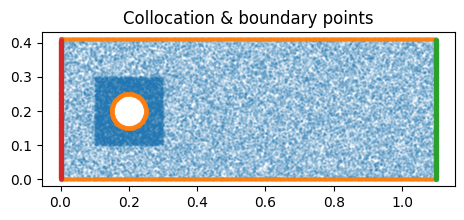

2026-02-03 16:45:31.704653: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-03 16:45:31.704717: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-03 16:45:31.704724: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-03 16:45:31.704870: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-03 16:45:31.704880: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


It      0 | loss=1.983e+00 | f=2.052e-01 wall=4.524e-02 in=8.320e-01 out=1.160e-02
It     10 | loss=7.003e-01 | f=7.286e-02 wall=1.657e-01 in=1.478e-01 out=1.352e-04
It     20 | loss=6.128e-01 | f=2.542e-02 wall=9.955e-02 in=1.929e-01 out=1.298e-03
It     30 | loss=5.713e-01 | f=3.224e-03 wall=1.017e-01 in=1.816e-01 out=7.632e-04
It     40 | loss=5.560e-01 | f=3.326e-03 wall=1.153e-01 in=1.607e-01 out=3.576e-04
It     50 | loss=5.359e-01 | f=2.537e-03 wall=9.336e-02 in=1.733e-01 out=8.960e-06
It     60 | loss=5.090e-01 | f=2.868e-03 wall=1.034e-01 in=1.497e-01 out=3.712e-05
It     70 | loss=4.782e-01 | f=4.736e-03 wall=8.789e-02 in=1.488e-01 out=6.470e-05
It     80 | loss=4.472e-01 | f=8.398e-03 wall=8.176e-02 in=1.376e-01 out=4.320e-05
It     90 | loss=4.225e-01 | f=1.267e-02 wall=7.324e-02 in=1.316e-01 out=3.895e-05
It    100 | loss=4.065e-01 | f=1.448e-02 wall=6.789e-02 in=1.281e-01 out=4.357e-05
It    110 | loss=3.958e-01 | f=1.195e-02 wall=6.490e-02 in=1.270e-01 out=3.068e-05
It  

In [4]:

# =========================
# Main (same as your TF1)
# =========================

# Domain bounds
lb = np.array([0.0, 0.0])
ub = np.array([1.1, 0.41])

# Network configuration
uv_layers = [2] + 8*[40] + [5]

# ---- Boundary points (fixed to avoid list/array mixing issues) ----
L, H = 1.1, 0.41

# WALL (top/bottom)
Nw = 441
wall_up = np.hstack([L*lhs(1, Nw), H*np.ones((Nw,1))])
wall_lw = np.hstack([L*lhs(1, Nw), 0.0*np.ones((Nw,1))])

# INLET (x=0, parabolic)
U_max = 1.0
Ni = 201
y_in = H*lhs(1, Ni)
x_in = np.zeros((Ni,1))
u_in = 4*U_max*y_in*(H-y_in)/(H**2)
v_in = np.zeros_like(u_in)
INLET = np.hstack([x_in, y_in, u_in, v_in])

# OUTLET (x=L)
No = 201
OUTLET = np.hstack([L*np.ones((No,1)), H*lhs(1, No)])

# Cylinder boundary
r = 0.05
Nc = 251
theta = 2*np.pi*lhs(1, Nc)
CYLD = np.hstack([0.2 + r*np.cos(theta), 0.2 + r*np.sin(theta)])

WALL = np.vstack([CYLD, wall_up, wall_lw])

# ---- Collocation points ----
XY_c = lb + (ub - lb) * lhs(2, 40000)
XY_c_refine = np.array([0.1, 0.1]) + np.array([0.2, 0.2]) * lhs(2, 10000)
XY_c = np.vstack([XY_c, XY_c_refine])
XY_c = DelCylPT(XY_c, xc=0.2, yc=0.2, r=0.05)

# include boundary points in collocation set
XY_c = np.vstack([XY_c, WALL, CYLD, OUTLET, INLET[:,0:2]])
print("Collo shape:", XY_c.shape)

# Visualize points
fig, ax = plt.subplots(figsize=(6,2))
ax.set_aspect('equal')
plt.scatter(XY_c[:,0], XY_c[:,1], s=1, alpha=0.1)
plt.scatter(WALL[:,0], WALL[:,1], s=5, alpha=0.4)
plt.scatter(OUTLET[:,0], OUTLET[:,1], s=8, alpha=0.6)
plt.scatter(INLET[:,0], INLET[:,1], s=8, alpha=0.6)
plt.title("Collocation & boundary points")
plt.show()

# ---- Train ----
model = PINN_laminar_flow_TF2(XY_c, INLET, OUTLET, WALL, uv_layers, lb, ub,
                             rho=1.0, mu=0.02, bc_weight=2.0)

start = time.time()
model.train_adam(iters=10000, lr=5e-4, print_every=10)
res = model.train_lbfgs(maxiter=50000)
print("Elapsed (s):", time.time() - start)


In [5]:
# Save weights
model.save("uvNN_tf2_weights.weights.h5")

In [6]:
def predict(self, x_star, y_star):
    x = tf.convert_to_tensor(x_star.astype(np.float32))
    y = tf.convert_to_tensor(y_star.astype(np.float32))
    u, v, p, *_ = self.uv_and_grads(x, y)
    return u.numpy(), v.numpy(), p.numpy()

def predict_all(self, x_star, y_star):
    x = tf.convert_to_tensor(x_star.astype(np.float32))
    y = tf.convert_to_tensor(y_star.astype(np.float32))
    u, v, p, s11, s22, s12, *_ = self.uv_and_grads(x, y)
    return u.numpy(), v.numpy(), p.numpy(), s11.numpy(), s22.numpy(), s12.numpy()


Relative L2 error on line: 0.041806489832837614


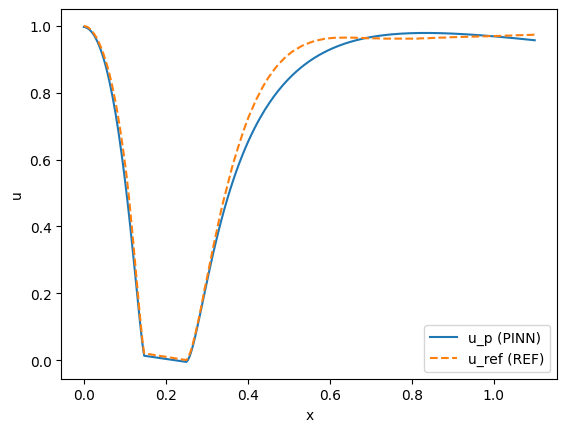

In [12]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
u_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=u_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = u_p.reshape(-1) - u_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(u_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, u_p, label="u_p (PINN)")
plt.plot(x_line_m, u_ref_line, "--", label="u_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("u"); plt.show()


Relative L2 error on line: 0.4453270677197891


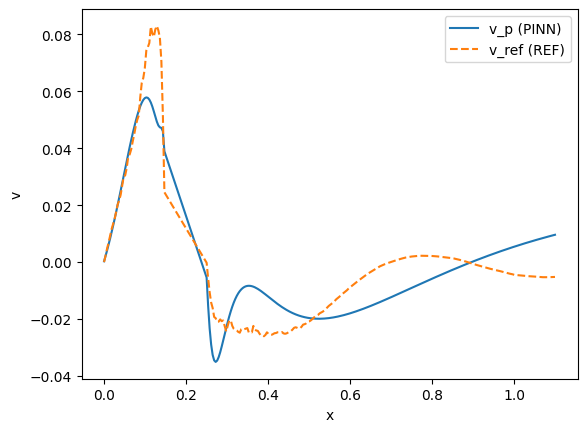

In [15]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
v_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=v_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = v_p.reshape(-1) - v_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(v_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, v_p, label="v_p (PINN)")
plt.plot(x_line_m, v_ref_line, "--", label="v_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("v"); plt.show()


Relative L2 error on line: 0.14288386683326312


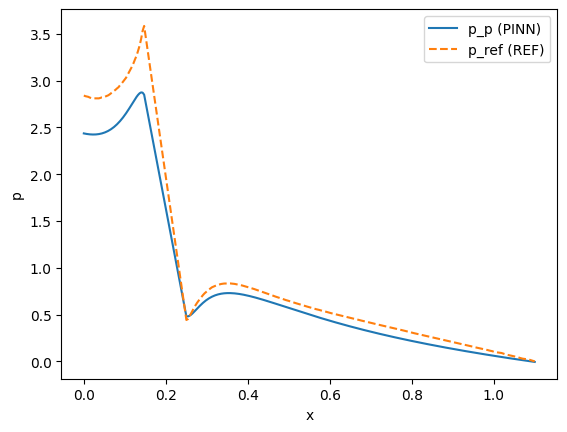

In [14]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
p_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=p_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = p_p.reshape(-1) - p_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(p_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, p_p, label="p_p (PINN)")
plt.plot(x_line_m, p_ref_line, "--", label="p_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("p"); plt.show()


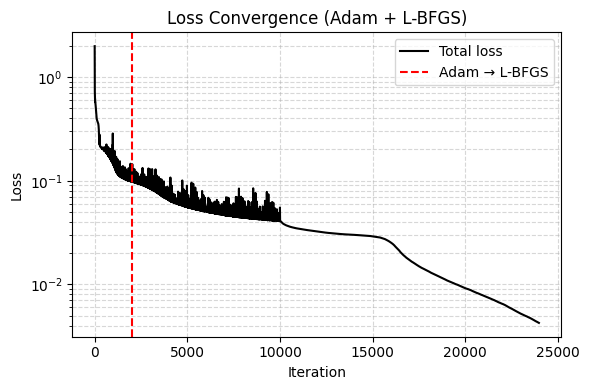

In [16]:
loss = np.array(model.loss_rec)
adam_iters = 10000  # number of Adam iterations

plt.figure(figsize=(6,4))
plt.semilogy(loss, 'k-', label="Total loss")
plt.axvline(adam_iters, color='r', ls='--', lw=1.5, label="Adam → L-BFGS")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss Convergence (Adam + L-BFGS)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


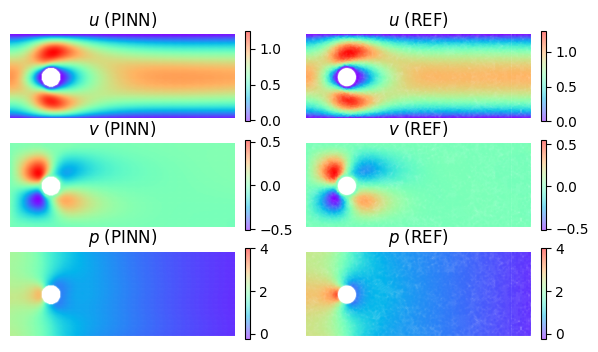

In [7]:

# ---- Compare with reference (optional) ----
# Change this path to your mat file:
x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")
field_ref = [x_ref, y_ref, u_ref, v_ref, p_ref]

# PINN prediction grid
xg = np.linspace(0, L, 251)
yg = np.linspace(0, H, 101)
Xg, Yg = np.meshgrid(xg, yg)
x_star = Xg.flatten()[:,None]
y_star = Yg.flatten()[:,None]
dst = np.sqrt((x_star-0.2)**2 + (y_star-0.2)**2)
mask = dst[:,0] >= r
x_star = x_star[mask]
y_star = y_star[mask]

u_p, v_p, p_p = model.predict(x_star, y_star)

field_pinn = [x_star, y_star, u_p, v_p, p_p]

# If you have field_ref, uncomment:
postProcess(0, L, 0, H, field_ref, field_pinn, s=3, alpha=0.5)


In [17]:
# continue L-BFGS from current weights (no code changes)
res2 = model.train_lbfgs(maxiter=50000, maxcor=50)


L-BFGS loss: 0.004255947656929493
L-BFGS loss: 0.004255796782672405
L-BFGS loss: 0.004255629610270262
L-BFGS loss: 0.004255305044353008
L-BFGS loss: 0.004254839848726988
L-BFGS loss: 0.004254274535924196
L-BFGS loss: 0.004254158586263657
L-BFGS loss: 0.004253724589943886
L-BFGS loss: 0.0042536137625575066
L-BFGS loss: 0.0042532761581242085
L-BFGS loss: 0.0042528994381427765
L-BFGS loss: 0.00425226055085659
L-BFGS loss: 0.004251915030181408
L-BFGS loss: 0.004251486621797085
L-BFGS loss: 0.0042512123472988605
L-BFGS loss: 0.0042506977915763855
L-BFGS loss: 0.004250126890838146
L-BFGS loss: 0.0042495811358094215
L-BFGS loss: 0.00424926308915019
L-BFGS loss: 0.004248968791216612
L-BFGS loss: 0.004248594865202904
L-BFGS loss: 0.004247923381626606
L-BFGS loss: 0.004247575532644987
L-BFGS loss: 0.0042471266351640224
L-BFGS loss: 0.004246686585247517
L-BFGS loss: 0.00424631591886282
L-BFGS loss: 0.004245457239449024
L-BFGS loss: 0.004244459327310324
L-BFGS loss: 0.004243819043040276
L-BFGS los

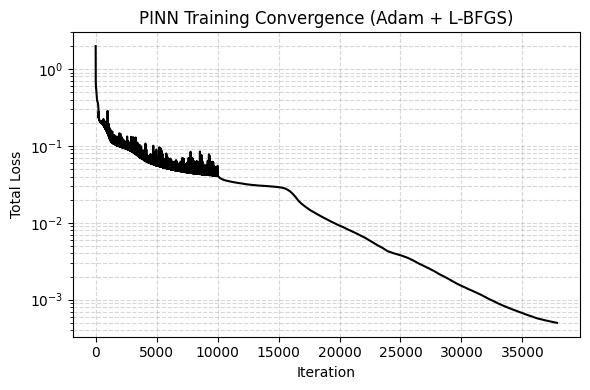

In [18]:
import matplotlib.pyplot as plt
import numpy as np

loss = np.array(model.loss_rec)

plt.figure(figsize=(6,4))
plt.semilogy(loss, 'k-')
plt.xlabel("Iteration")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence (Adam + L-BFGS)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [20]:
# Save weights
model.save("uvNN_tf2_weights_2nd.weights.h5")

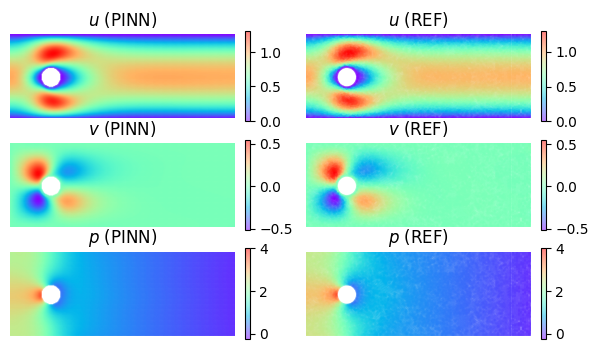

In [21]:

# ---- Compare with reference (optional) ----
# Change this path to your mat file:
x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")
field_ref = [x_ref, y_ref, u_ref, v_ref, p_ref]

# PINN prediction grid
xg = np.linspace(0, L, 251)
yg = np.linspace(0, H, 101)
Xg, Yg = np.meshgrid(xg, yg)
x_star = Xg.flatten()[:,None]
y_star = Yg.flatten()[:,None]
dst = np.sqrt((x_star-0.2)**2 + (y_star-0.2)**2)
mask = dst[:,0] >= r
x_star = x_star[mask]
y_star = y_star[mask]

u_p, v_p, p_p = model.predict(x_star, y_star)

field_pinn = [x_star, y_star, u_p, v_p, p_p]

# If you have field_ref, uncomment:
postProcess(0, L, 0, H, field_ref, field_pinn, s=3, alpha=0.5)


Relative L2 error on line: 0.023707110153400778


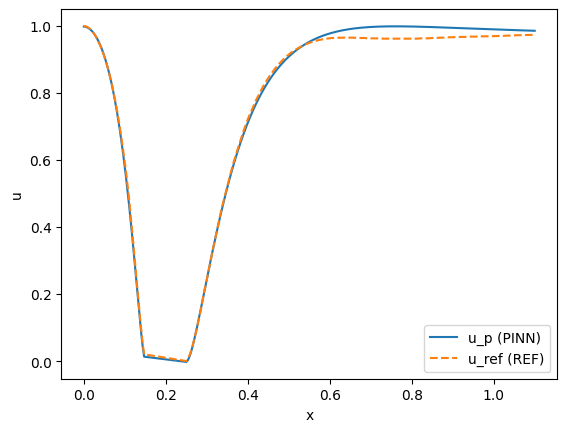

In [22]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
u_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=u_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = u_p.reshape(-1) - u_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(u_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, u_p, label="u_p (PINN)")
plt.plot(x_line_m, u_ref_line, "--", label="u_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("u"); plt.show()


Relative L2 error on line: 0.20754317922228963


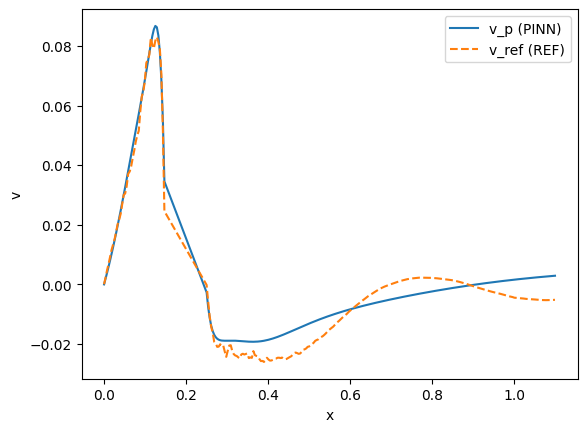

In [24]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
v_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=v_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = v_p.reshape(-1) - v_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(v_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, v_p, label="v_p (PINN)")
plt.plot(x_line_m, v_ref_line, "--", label="v_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("v"); plt.show()


Relative L2 error on line: 0.034182585558501934


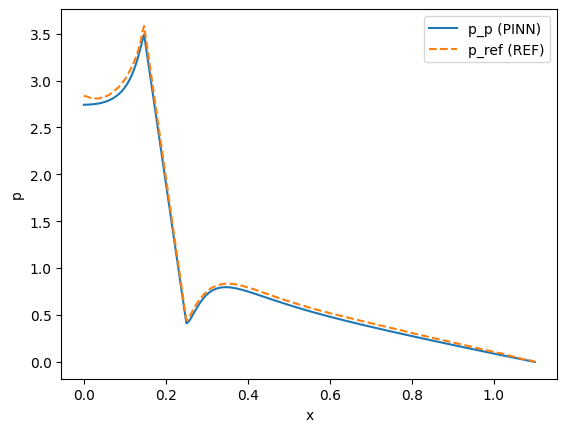

In [25]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
p_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=p_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = p_p.reshape(-1) - p_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(p_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, p_p, label="p_p (PINN)")
plt.plot(x_line_m, p_ref_line, "--", label="p_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("p"); plt.show()


In [26]:
# continue L-BFGS from current weights (no code changes)
res3 = model.train_lbfgs(maxiter=50000, maxcor=50)

L-BFGS loss: 0.0004991197492927313
L-BFGS loss: 0.0004991184687241912
L-BFGS loss: 0.0004991131136193871
L-BFGS loss: 0.0004991015302948654
L-BFGS loss: 0.0004990841844119132
L-BFGS loss: 0.0004990790621377528
L-BFGS loss: 0.0004990678862668574
L-BFGS loss: 0.0004990625311620533
L-BFGS loss: 0.0004990501329302788
L-BFGS loss: 0.0004990356392227113
L-BFGS loss: 0.0004990211455151439
L-BFGS loss: 0.0004990047309547663
L-BFGS loss: 0.0004989890730939806
L-BFGS loss: 0.0004989748704247177
L-BFGS loss: 0.0004989628796465695
L-BFGS loss: 0.0004989368026144803
L-BFGS loss: 0.000498923531267792
L-BFGS loss: 0.0004989043809473515
L-BFGS loss: 0.000498890527524054
L-BFGS loss: 0.0004988671280443668
L-BFGS loss: 0.0004988344735465944
L-BFGS loss: 0.0004988299333490431
L-BFGS loss: 0.0004987942520529032
L-BFGS loss: 0.0004987838910892606
L-BFGS loss: 0.000498769513797015
L-BFGS loss: 0.0004987505963072181
L-BFGS loss: 0.0004987170686945319
L-BFGS loss: 0.0004986879648640752
L-BFGS loss: 0.00049867

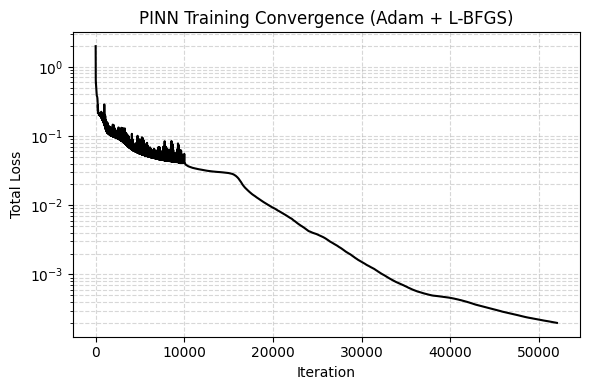

In [27]:
import matplotlib.pyplot as plt
import numpy as np

loss = np.array(model.loss_rec)

plt.figure(figsize=(6,4))
plt.semilogy(loss, 'k-')
plt.xlabel("Iteration")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence (Adam + L-BFGS)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [28]:
# Save weights
model.save("uvNN_tf2_weights_3rd.weights.h5")

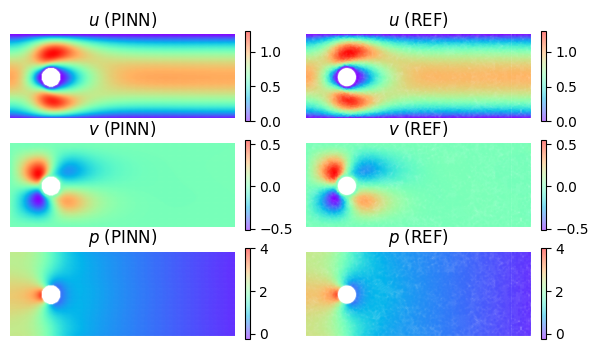

In [29]:

# ---- Compare with reference (optional) ----
# Change this path to your mat file:
x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")
field_ref = [x_ref, y_ref, u_ref, v_ref, p_ref]

# PINN prediction grid
xg = np.linspace(0, L, 251)
yg = np.linspace(0, H, 101)
Xg, Yg = np.meshgrid(xg, yg)
x_star = Xg.flatten()[:,None]
y_star = Yg.flatten()[:,None]
dst = np.sqrt((x_star-0.2)**2 + (y_star-0.2)**2)
mask = dst[:,0] >= r
x_star = x_star[mask]
y_star = y_star[mask]

u_p, v_p, p_p = model.predict(x_star, y_star)

field_pinn = [x_star, y_star, u_p, v_p, p_p]

# If you have field_ref, uncomment:
postProcess(0, L, 0, H, field_ref, field_pinn, s=3, alpha=0.5)


Relative L2 error on line: 0.026098753132920385


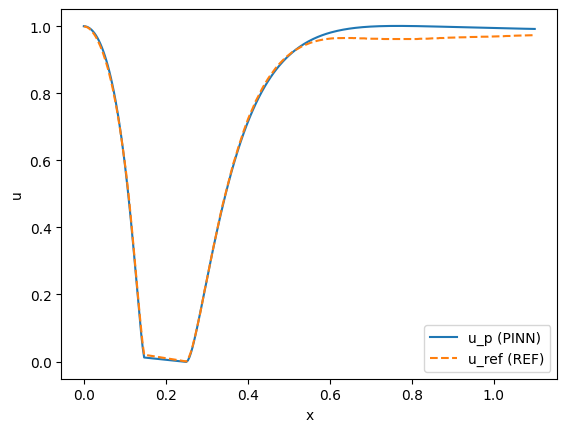

In [30]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
u_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=u_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = u_p.reshape(-1) - u_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(u_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, u_p, label="u_p (PINN)")
plt.plot(x_line_m, u_ref_line, "--", label="u_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("u"); plt.show()


Relative L2 error on line: 0.23407295637011083


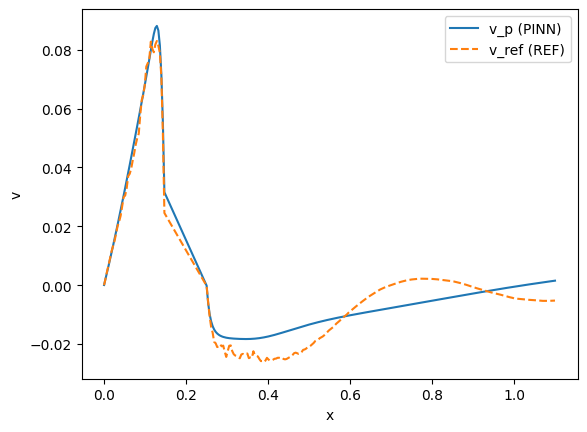

In [31]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
v_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=v_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = v_p.reshape(-1) - v_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(v_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, v_p, label="v_p (PINN)")
plt.plot(x_line_m, v_ref_line, "--", label="v_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("v"); plt.show()


Relative L2 error on line: 0.02761106502375344


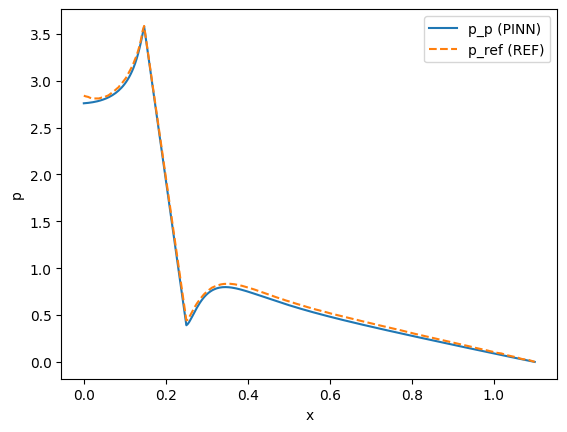

In [32]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
p_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=p_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = p_p.reshape(-1) - p_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(p_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, p_p, label="p_p (PINN)")
plt.plot(x_line_m, p_ref_line, "--", label="p_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("p"); plt.show()


In [33]:
# continue L-BFGS from current weights (no code changes)
res4 = model.train_lbfgs(maxiter=50000, maxcor=50)

L-BFGS loss: 0.00019918680482078344
L-BFGS loss: 0.0001991853496292606
L-BFGS loss: 0.00019918281759601086
L-BFGS loss: 0.00019917686586268246
L-BFGS loss: 0.00019917305326089263
L-BFGS loss: 0.0001991691387956962
L-BFGS loss: 0.00019916871679015458
L-BFGS loss: 0.00019916497694794089
L-BFGS loss: 0.00019916315795853734
L-BFGS loss: 0.00019915716256946325
L-BFGS loss: 0.00019915285520255566
L-BFGS loss: 0.00019914803851861507
L-BFGS loss: 0.00019914460426662117
L-BFGS loss: 0.00019914192671421915
L-BFGS loss: 0.00019913900177925825
L-BFGS loss: 0.00019913175492547452
L-BFGS loss: 0.00019912868447136134
L-BFGS loss: 0.0001991229219129309
L-BFGS loss: 0.00019911849813070148
L-BFGS loss: 0.00019911340496037155
L-BFGS loss: 0.0001991049648495391
L-BFGS loss: 0.0001990966993616894
L-BFGS loss: 0.00019909163529518992
L-BFGS loss: 0.00019908708054572344
L-BFGS loss: 0.00019908371905330569
L-BFGS loss: 0.00019907698151655495
L-BFGS loss: 0.00019906485977116972
L-BFGS loss: 0.000199052927200682

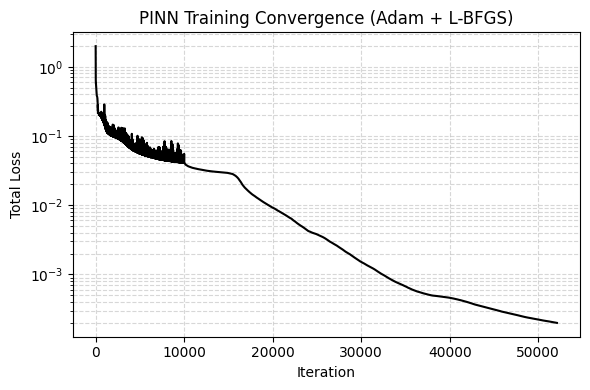

In [34]:
import matplotlib.pyplot as plt
import numpy as np

loss = np.array(model.loss_rec)

plt.figure(figsize=(6,4))
plt.semilogy(loss, 'k-')
plt.xlabel("Iteration")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence (Adam + L-BFGS)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [35]:
# Save weights
model.save("uvNN_tf2_weights_4th.weights.h5")

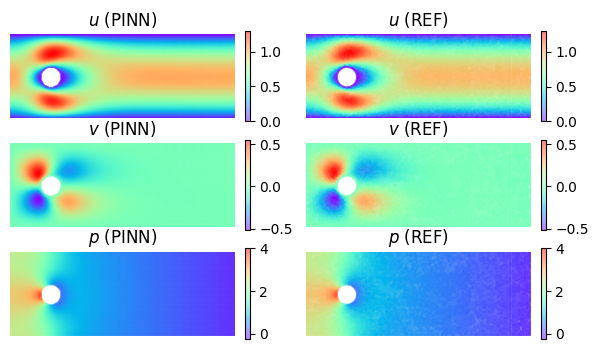

In [36]:

# ---- Compare with reference (optional) ----
# Change this path to your mat file:
x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")
field_ref = [x_ref, y_ref, u_ref, v_ref, p_ref]

# PINN prediction grid
xg = np.linspace(0, L, 251)
yg = np.linspace(0, H, 101)
Xg, Yg = np.meshgrid(xg, yg)
x_star = Xg.flatten()[:,None]
y_star = Yg.flatten()[:,None]
dst = np.sqrt((x_star-0.2)**2 + (y_star-0.2)**2)
mask = dst[:,0] >= r
x_star = x_star[mask]
y_star = y_star[mask]

u_p, v_p, p_p = model.predict(x_star, y_star)

field_pinn = [x_star, y_star, u_p, v_p, p_p]

# If you have field_ref, uncomment:
postProcess(0, L, 0, H, field_ref, field_pinn, s=3, alpha=0.5)


Relative L2 error on line: 0.026006361364922837


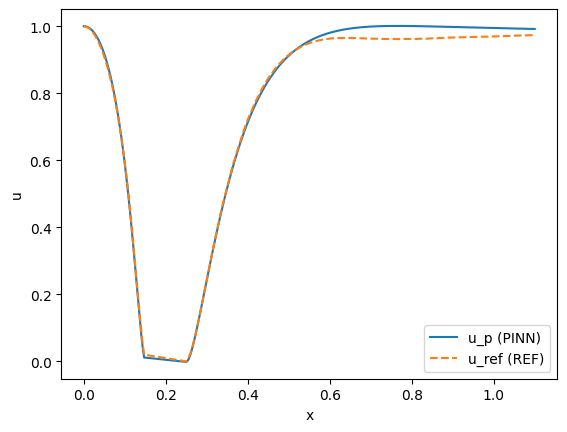

In [37]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
u_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=u_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = u_p.reshape(-1) - u_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(u_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, u_p, label="u_p (PINN)")
plt.plot(x_line_m, u_ref_line, "--", label="u_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("u"); plt.show()


Relative L2 error on line: 0.2344307346109838


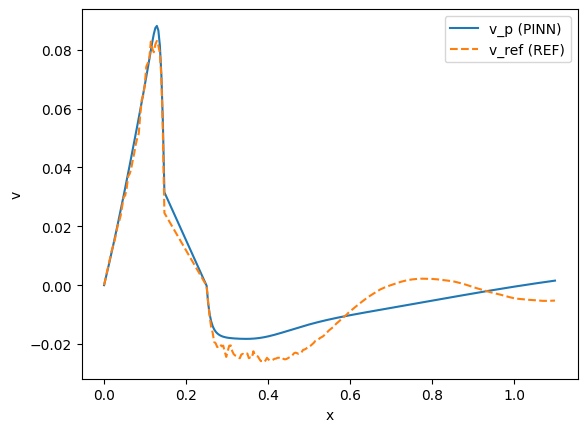

In [38]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
v_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=v_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = v_p.reshape(-1) - v_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(v_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, v_p, label="v_p (PINN)")
plt.plot(x_line_m, v_ref_line, "--", label="v_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("v"); plt.show()


Relative L2 error on line: 0.027579887687027776


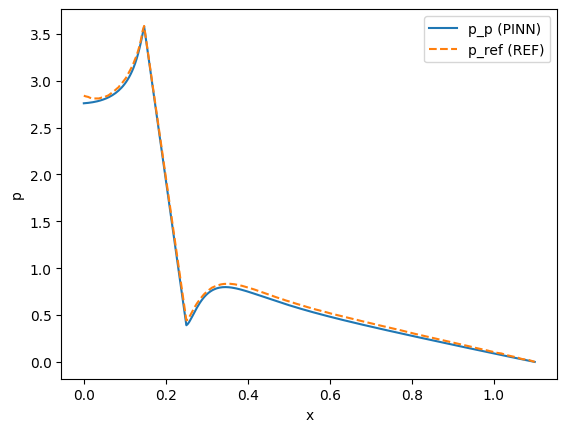

In [39]:
y0 = 0.205
x_line = np.linspace(0.0, 1.1, 300)[:, None]
y_line = y0 * np.ones_like(x_line)

# remove cylinder interior
r = 0.05
dst = np.sqrt((x_line-0.2)**2 + (y_line-0.2)**2)
mask = (dst[:,0] >= r)
x_line_m = x_line[mask]
y_line_m = y_line[mask]

# PINN prediction
u_p, v_p, p_p = model.predict(x_line_m, y_line_m)

# REF interpolation onto same line points
from scipy.interpolate import griddata
p_ref_line = griddata(
    points=np.hstack([x_ref, y_ref]),
    values=p_ref.reshape(-1),
    xi=np.hstack([x_line_m, y_line_m]),
    method="linear"
)

# error metrics on that line
err = p_p.reshape(-1) - p_ref_line.reshape(-1)
L2_rel = np.linalg.norm(err) / (np.linalg.norm(p_ref_line) + 1e-12)
print("Relative L2 error on line:", L2_rel)

# plot comparison
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x_line_m, p_p, label="p_p (PINN)")
plt.plot(x_line_m, p_ref_line, "--", label="p_ref (REF)")
plt.legend(); plt.xlabel("x"); plt.ylabel("p"); plt.show()


/var/folders/qq/0y83lt2x4z78hjpkv8jj_yh00000gn/T/ipykernel_59575/2854735315.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


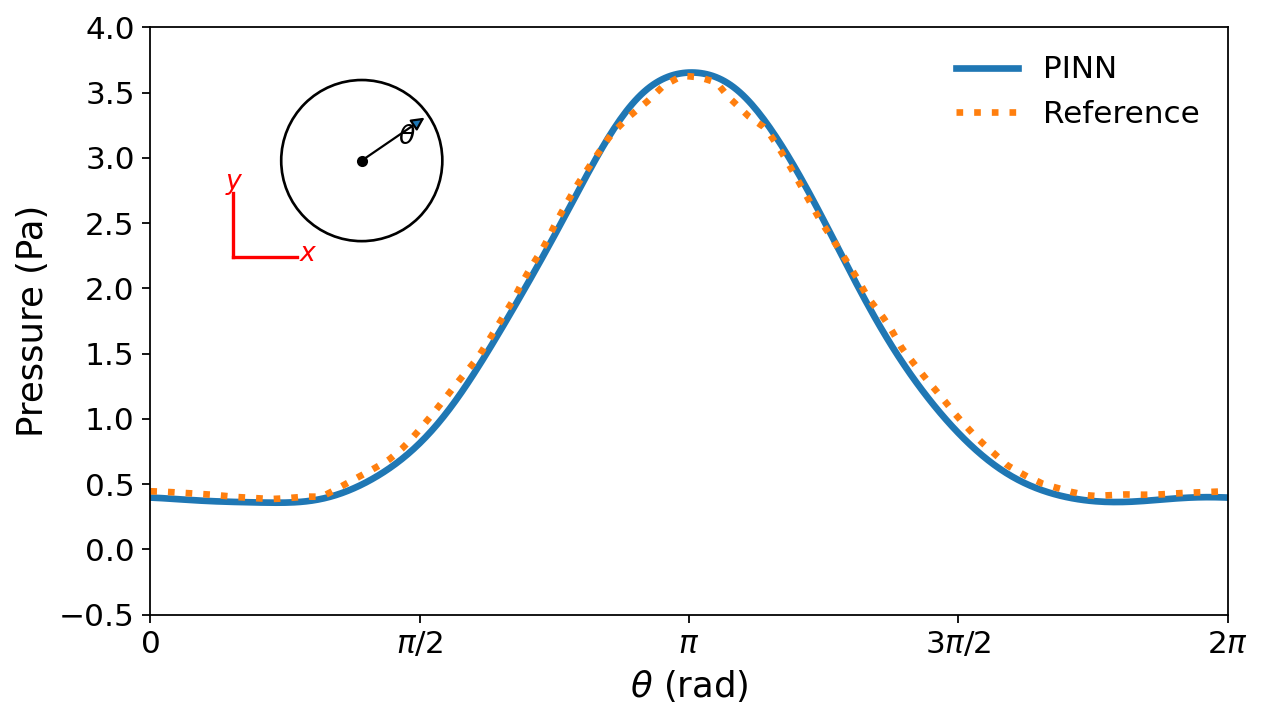

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.patches import Circle, FancyArrowPatch

def pressure_on_cylinder(theta, xc, yc, r, p_func=None, ref_data=None, method="linear"):
    x = xc + r*np.cos(theta)
    y = yc + r*np.sin(theta)

    if p_func is not None:
        p = p_func(x[:, None], y[:, None]).reshape(-1)
        return p

    if ref_data is not None:
        x_ref, y_ref, p_ref = ref_data
        pts_ref = np.hstack([x_ref.reshape(-1,1), y_ref.reshape(-1,1)])
        pts_q   = np.hstack([x.reshape(-1,1),     y.reshape(-1,1)])
        p = griddata(pts_ref, p_ref.reshape(-1), pts_q, method=method)

        # fill NaNs if any
        if np.any(np.isnan(p)):
            p2 = griddata(pts_ref, p_ref.reshape(-1), pts_q, method="nearest")
            p = np.where(np.isnan(p), p2, p)

        return p.reshape(-1)

    raise ValueError("Provide either p_func or ref_data.")

def plot_pressure_distribution(theta, p_pred, p_ref, ylim=(-0.5, 4.0)):
    fig, ax = plt.subplots(figsize=(8,4.6), dpi=160)

    ax.plot(theta, p_pred, lw=3.0, label="PINN")   # <- your p_pred
    ax.plot(theta, p_ref,  lw=3.0, ls=":", label="Reference")

    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r'$\theta$ (rad)', fontsize=16)
    ax.set_ylabel('Pressure (Pa)', fontsize=16)

    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.legend(frameon=False, fontsize=14, loc="upper right")

    # inset sketch (cylinder + theta arrow + x/y axes)
    ax_in = fig.add_axes([0.18, 0.62, 0.18, 0.28])
    ax_in.set_aspect('equal')
    ax_in.axis('off')

    ax_in.add_patch(Circle((0,0), 1.0, fill=False, lw=1.2))
    ax_in.plot([0],[0],'ko', ms=4)

    th0 = 0.6
    ax_in.add_patch(FancyArrowPatch((0,0), (np.cos(th0), np.sin(th0)),
                                    arrowstyle='-|>', mutation_scale=12, lw=1.0))
    ax_in.text(0.45, 0.2, r'$\theta$', fontsize=12)

    ax_in.plot([-1.6, -0.8], [-1.2, -1.2], color='red', lw=1.5)
    ax_in.plot([-1.6, -1.6], [-1.2, -0.4], color='red', lw=1.5)
    ax_in.text(-0.78, -1.25, r'$x$', color='red', fontsize=12)
    ax_in.text(-1.7, -0.35, r'$y$', color='red', fontsize=12)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Usage with your model + reference
# ----------------------------
xc, yc, r = 0.2, 0.2, 0.05
theta = np.linspace(0, 2*np.pi, 361)

# p_pred from PINN (mixed)
p_pred = pressure_on_cylinder(
    theta, xc, yc, r,
    p_func=lambda x, y: model.predict(x, y)[2]   # model.predict returns (u,v,p)
)

# reference (from preprocess_mat)
# x_ref, y_ref, u_ref, v_ref, p_ref = preprocess_mat("FluentSol.mat")
p_ref_curve = pressure_on_cylinder(
    theta, xc, yc, r,
    ref_data=(x_ref, y_ref, p_ref),
    method="linear"
)

plot_pressure_distribution(theta, p_pred, p_ref_curve, ylim=(-0.5, 4.0))


In [42]:
results = {
    "loss_history": model.loss_rec,
    "theta": theta,
    "p_pred": p_pred,
    "p_ref": p_ref,
    "meta": {
        "rho": 1.0,
        "mu": 0.02,
        "layers": uv_layers,
        "bc_weight": 2.0,
        "description": "2D cylinder laminar flow, mixed PINN"
    }
}

with open("pinn_cylinder_results.pkl", "wb") as f:
    pickle.dump(results, f)
